In [1]:
import pandas as pd
import numpy as np
import h5py
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import warnings
import pickle
from datetime import datetime
import json
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():    
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Memory: 47.7 GB

GPU Name: NVIDIA L40S


# Hybrid CNN + Metadata Model for ISIC Competition

## Key Improvements:
1. ✅ Uses metadata features (14 numerical + 4 categorical)
2. ✅ Hybrid architecture: CNN for images + MLP for metadata
3. ✅ Focal Loss to handle extreme class imbalance (1:1168)
4. ✅ Proper feature preprocessing and encoding
5. ✅ Better evaluation metrics and threshold tuning
6. ✅ **Results saving**: All training results saved to timestamped folders

Expected AUC improvement: 0.51 → 0.70-0.80

---

## Configuration: Load Previous Results or Train New Model

Set `LOAD_EXISTING_RESULTS = True` to load a previous training run and skip training.
This allows you to regenerate visualizations without retraining.

In [15]:
# ========================================
# CONFIGURATION: Load existing or train new
# ========================================

# Set to True to load a previous training run (skip training)
LOAD_EXISTING_RESULTS = False

# If loading, specify which results folder to use (leave None to use most recent)
RESULTS_FOLDER = None  # e.g., 'results/hybrid_model_20241107_123456'

# ========================================

if LOAD_EXISTING_RESULTS:
    results_base = Path('results')
    
    if RESULTS_FOLDER is None:
        # Find most recent results folder
        result_folders = sorted(results_base.glob('hybrid_model_*'))
        if not result_folders:
            raise ValueError("No existing results found! Set LOAD_EXISTING_RESULTS=False to train a new model.")
        results_dir = result_folders[-1]
    else:
        results_dir = Path(RESULTS_FOLDER)
        if not results_dir.exists():
            raise ValueError(f"Results folder not found: {results_dir}")
    
    print("=" * 70)
    print("LOADING EXISTING RESULTS")
    print("=" * 70)
    print(f"Results directory: {results_dir}")
    
    # Load training results
    with open(results_dir / 'training_results.pkl', 'rb') as f:
        loaded_results = pickle.load(f)
    
    # Extract variables
    timestamp = loaded_results['timestamp']
    best_auc = loaded_results['best_auc']
    history = loaded_results['history']
    total_time = loaded_results['total_time']
    BATCH_SIZE = loaded_results['batch_size']
    NUM_WORKERS = loaded_results['num_workers']
    metadata_dim = loaded_results['metadata_dim']
    NUMERICAL_FEATURES = loaded_results['numerical_features']
    CATEGORICAL_FEATURES = loaded_results['categorical_features']
    total_params = loaded_results['total_params']
    trainable_params = loaded_results['trainable_params']
    
    # Load preprocessors
    with open(results_dir / 'preprocessors.pkl', 'rb') as f:
        preprocessors = pickle.load(f)
        scaler = preprocessors['scaler']
        encoders = preprocessors['encoders']
    
    # Load optimal threshold if exists
    threshold_file = results_dir / 'optimal_threshold.json'
    if threshold_file.exists():
        with open(threshold_file, 'r') as f:
            threshold_data = json.load(f)
            optimal_threshold = threshold_data['optimal_threshold']
    else:
        optimal_threshold = None
    
    print(f"✓ Loaded results from training run: {timestamp}")
    print(f"  Best AUC: {best_auc:.4f}")
    print(f"  Epochs: {len(history['train_auc'])}")
    print(f"  Total time: {total_time/60:.1f} minutes")
    if optimal_threshold:
        print(f"  Optimal threshold: {optimal_threshold:.4f}")
    print("=" * 70 + "\n")
    
    print("⏭️  Skip to visualization cells (after training loop) to regenerate plots")
    print("   or continue to load data and model for predictions.\n")
else:
    print("=" * 70)
    print("TRAINING NEW MODEL")
    print("=" * 70)
    print("Will create new timestamped results folder during training.\n")

TRAINING NEW MODEL
Will create new timestamped results folder during training.



## 1. Metadata Preprocessing

In [2]:
# Load metadata
data_dir = Path('data')
train_meta = pd.read_csv(data_dir / 'new-train-metadata.csv', low_memory=False)
test_meta = pd.read_csv(data_dir / 'students-test-metadata.csv', low_memory=False)

print("Metadata loaded:")
print(f"  Train: {len(train_meta):,} samples")
print(f"  Test: {len(test_meta):,} samples")
print(f"  Positive rate: {train_meta['target'].mean():.4f}\n")

Metadata loaded:
  Train: 400,959 samples
  Test: 100 samples
  Positive rate: 0.0009



In [4]:
# Define features to use (from analysis)
NUMERICAL_FEATURES = [
    'tbp_lv_H', 'tbp_lv_areaMM2', 'tbp_lv_minorAxisMM',
    'tbp_lv_perimeterMM', 'tbp_lv_deltaB', 'tbp_lv_Hext',
    'clin_size_long_diam_mm', 'tbp_lv_radial_color_std_max',
    'tbp_lv_B', 'tbp_lv_color_std_mean', 'tbp_lv_Aext',
    'tbp_lv_stdLExt', 'tbp_lv_norm_color', 'tbp_lv_A',
    'age_approx'  # Added age as it's often useful
]

CATEGORICAL_FEATURES = [
    'sex', 'anatom_site_general', 'tbp_tile_type', 'tbp_lv_location_simple'
]

print(f"Selected features:")
print(f"  Numerical: {len(NUMERICAL_FEATURES)}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}\n")

Selected features:
  Numerical: 15
  Categorical: 4



In [5]:
def preprocess_metadata(df, is_train=True, scaler=None, encoders=None):
    """
    Preprocess metadata: handle missing values, normalize, encode categoricals
    """
    df = df.copy()
    
    # 1. Handle missing values in numerical features
    for col in NUMERICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median() if is_train else 0)
    
    # 2. Handle missing values in categorical features
    for col in CATEGORICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].fillna('missing')
    
    # 3. Normalize numerical features
    if is_train:
        scaler = StandardScaler()
        df[NUMERICAL_FEATURES] = scaler.fit_transform(df[NUMERICAL_FEATURES])
    else:
        df[NUMERICAL_FEATURES] = scaler.transform(df[NUMERICAL_FEATURES])
    
    # 4. One-hot encode categorical features
    if is_train:
        encoders = {}
        encoded_dfs = []
        for col in CATEGORICAL_FEATURES:
            encoded = pd.get_dummies(df[col], prefix=col, dtype=float)
            encoders[col] = encoded.columns.tolist()
            encoded_dfs.append(encoded)
        
        # Combine numerical and encoded categorical
        result_df = pd.concat([df[NUMERICAL_FEATURES]] + encoded_dfs, axis=1)
    else:
        encoded_dfs = []
        for col in CATEGORICAL_FEATURES:
            encoded = pd.get_dummies(df[col], prefix=col, dtype=float)
            # Ensure same columns as training
            for train_col in encoders[col]:
                if train_col not in encoded.columns:
                    encoded[train_col] = 0
            encoded = encoded[encoders[col]]
            encoded_dfs.append(encoded)
        
        result_df = pd.concat([df[NUMERICAL_FEATURES]] + encoded_dfs, axis=1)
    
    return result_df, scaler, encoders

# Preprocess train metadata
print("Preprocessing metadata...")
train_meta_processed, scaler, encoders = preprocess_metadata(train_meta, is_train=True)
test_meta_processed, _, _ = preprocess_metadata(test_meta, is_train=False, scaler=scaler, encoders=encoders)

# Add back isic_id and target
train_meta_processed['isic_id'] = train_meta['isic_id'].values
train_meta_processed['target'] = train_meta['target'].values
test_meta_processed['isic_id'] = test_meta['isic_id'].values

metadata_dim = len(train_meta_processed.columns) - 2  # Exclude isic_id and target
print(f"\nMetadata feature dimension: {metadata_dim}")
print(f"  Numerical: {len(NUMERICAL_FEATURES)}")
print(f"  Encoded categorical: {metadata_dim - len(NUMERICAL_FEATURES)}\n")

Preprocessing metadata...

Metadata feature dimension: 34
  Numerical: 15
  Encoded categorical: 19



## 2. Hybrid Dataset Class

In [6]:
class HybridDataset(Dataset):
    """
    Dataset that returns both images and metadata features
    """
    
    def __init__(self, hdf5_path, metadata_df, transform=None, is_test=False):
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.is_test = is_test
        self.hdf5_file = None
        
        # Match metadata with available images
        with h5py.File(hdf5_path, 'r') as f:
            available_ids = set(f.keys())
        
        self.metadata = metadata_df[
            metadata_df['isic_id'].isin(available_ids)
        ].reset_index(drop=True)
        
        # Extract metadata features (all columns except isic_id and target)
        feature_cols = [col for col in self.metadata.columns 
                       if col not in ['isic_id', 'target']]
        self.metadata_features = self.metadata[feature_cols].values.astype(np.float32)
        
        print(f"✓ Loaded {len(self.metadata)} samples from {Path(hdf5_path).name}")
        print(f"  Metadata shape: {self.metadata_features.shape}")
        
        if not is_test and 'target' in self.metadata.columns:
            dist = self.metadata['target'].value_counts()
            print(f"  Class distribution: {dist.to_dict()}")
    
    def _ensure_hdf5_open(self):
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, 'r', swmr=True)
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        self._ensure_hdf5_open()
        
        row = self.metadata.iloc[idx]
        image_id = row['isic_id']
        
        # Load image
        img_array = self.hdf5_file[image_id][:]
        image = Image.fromarray(img_array)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        
        # Get metadata features
        metadata = torch.tensor(self.metadata_features[idx], dtype=torch.float32)
        
        if self.is_test:
            return image, metadata, image_id
        else:
            label = row['target']
            return image, metadata, label

## 3. Create Datasets and DataLoaders

In [7]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split train/val
train_df, val_df = train_test_split(
    train_meta_processed,
    test_size=0.2,
    random_state=42,
    stratify=train_meta_processed['target']
)

print(f"Train/Val split: {len(train_df):,} / {len(val_df):,}\n")

# Create datasets
print("Creating datasets...")
train_dataset = HybridDataset(
    hdf5_path=data_dir / 'train-image-preprocessed.hdf5',
    metadata_df=train_df,
    transform=train_transform,
    is_test=False
)

val_dataset = HybridDataset(
    hdf5_path=data_dir / 'train-image-preprocessed.hdf5',
    metadata_df=val_df,
    transform=val_transform,
    is_test=False
)

test_dataset = HybridDataset(
    hdf5_path=data_dir / 'test-image-preprocessed.hdf5',
    metadata_df=test_meta_processed,
    transform=val_transform,
    is_test=True
)

# DataLoaders
BATCH_SIZE = 512
NUM_WORKERS = 16

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

print(f"\nDataLoader configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Num workers: {NUM_WORKERS}")
print(f"  Batches per epoch: {len(train_loader)} train, {len(val_loader)} val\n")

Train/Val split: 320,767 / 80,192

Creating datasets...
✓ Loaded 320767 samples from train-image-preprocessed.hdf5
  Metadata shape: (320767, 34)
  Class distribution: {0: 320493, 1: 274}
✓ Loaded 80192 samples from train-image-preprocessed.hdf5
  Metadata shape: (80192, 34)
  Class distribution: {0: 80123, 1: 69}
✓ Loaded 100 samples from test-image-preprocessed.hdf5
  Metadata shape: (100, 34)

DataLoader configuration:
  Batch size: 512
  Num workers: 16
  Batches per epoch: 627 train, 157 val



## 4. Focal Loss (for extreme class imbalance)

In [8]:
class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    
    Args:
        alpha: weighting factor (0-1), higher for minority class
        gamma: focusing parameter (>=0), higher focuses more on hard examples
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        # BCE loss
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        
        # Calculate p_t
        p_t = torch.exp(-bce_loss)
        
        # Calculate focal term
        focal_term = (1 - p_t) ** self.gamma
        
        # Focal loss
        focal_loss = self.alpha * focal_term * bce_loss
        
        return focal_loss.mean()

print("Focal Loss configured:")
print("  alpha=0.25 (weight for positive class)")
print("  gamma=2.0 (focus on hard examples)\n")

Focal Loss configured:
  alpha=0.25 (weight for positive class)
  gamma=2.0 (focus on hard examples)



## 5. Hybrid Model Architecture

In [10]:
class CNNFeatureExtractor(nn.Module):
    """CNN for extracting image features"""
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        # Output: 256 * 14 * 14 = 50,176 -> reduce to 512
        self.fc = nn.Linear(256 * 14 * 14, 512)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc(x)))
        return x


class MetadataProcessor(nn.Module):
    """MLP for processing metadata features"""
    def __init__(self, input_dim):
        super().__init__()
        
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
    
    def forward(self, x):
        return self.fc(x)


class HybridModel(nn.Module):
    """Hybrid model combining CNN and metadata"""
    def __init__(self, metadata_dim):
        super().__init__()
        
        self.cnn = CNNFeatureExtractor()  # -> 512 features
        self.metadata_processor = MetadataProcessor(metadata_dim)  # -> 64 features
        
        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    
    def forward(self, image, metadata):
        # Extract features
        img_features = self.cnn(image)
        meta_features = self.metadata_processor(metadata)
        
        # Combine
        combined = torch.cat([img_features, meta_features], dim=1)
        
        # Classify
        output = self.classifier(combined)
        return output


# Create model
model = HybridModel(metadata_dim=metadata_dim).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model created:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Device: {next(model.parameters()).device}\n")

Model created:
  Total parameters: 26,272,513
  Trainable parameters: 26,272,513
  Device: cuda:0



## 6. Training Setup

In [11]:
# Loss and optimizer
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=5,
    factor=0.5,
)

print("Training setup:")
print(f"  Loss: Focal Loss (alpha=0.25, gamma=2.0)")
print(f"  Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"  Scheduler: ReduceLROnPlateau (patience=5)\n")

Training setup:
  Loss: Focal Loss (alpha=0.25, gamma=2.0)
  Optimizer: Adam (lr=0.001, weight_decay=1e-5)
  Scheduler: ReduceLROnPlateau (patience=5)



## 7. Training and Validation Functions

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    start_time = time.time()
    
    for images, metadata, labels in tqdm(loader, desc="Training", ncols=100):
        images = images.to(device, non_blocking=True)
        metadata = metadata.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    elapsed = time.time() - start_time
    epoch_loss = running_loss / len(loader)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc, elapsed


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, metadata, labels in tqdm(loader, desc="Validation", ncols=100):
            images = images.to(device, non_blocking=True)
            metadata = metadata.to(device, non_blocking=True)
            labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
            
            outputs = model(images, metadata)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc, all_preds, all_labels

## 8. Training Loop

In [16]:
if not LOAD_EXISTING_RESULTS:
    NUM_EPOCHS = 30
    best_auc = 0.0
    history = {
        'train_loss': [], 'train_auc': [], 'train_time': [],
        'val_loss': [], 'val_auc': []
    }
    
    # Create results directory with timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    results_dir = Path('results') / f'hybrid_model_{timestamp}'
    results_dir.mkdir(parents=True, exist_ok=True)
    
    print("="*70)
    print("STARTING TRAINING")
    print("="*70)
    print(f"Results directory: {results_dir}")
    print(f"Epochs: {NUM_EPOCHS}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Model: Hybrid CNN + Metadata")
    print(f"Loss: Focal Loss")
    print("="*70 + "\n")
    
    total_start = time.time()
    
    for epoch in range(NUM_EPOCHS):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"{'='*70}")
        
        # Train
        train_loss, train_auc, train_time = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_auc, val_preds, val_labels = validate(
            model, val_loader, criterion, device
        )
        
        # Save metrics
        history['train_loss'].append(train_loss)
        history['train_auc'].append(train_auc)
        history['train_time'].append(train_time)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        
        # Print results
        print(f"\nResults:")
        print(f"  Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Time: {train_time:.1f}s")
        print(f"  Val Loss:   {val_loss:.4f} | Val AUC:   {val_auc:.4f}")
        
        # Save best model
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': val_auc,
                'scaler': scaler,
                'encoders': encoders
            }, results_dir / 'best_hybrid_model.pth')
            print(f"  ✓ Saved best model (AUC: {best_auc:.4f})")
        
        # Update learning rate
        scheduler.step(val_auc)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Learning rate: {current_lr:.6f}")
        
        # Early stopping
        if current_lr < 1e-6:
            print(f"\n  Learning rate too small, stopping early...")
            break
    
    total_time = time.time() - total_start
    
    # Save all training results
    results = {
        'timestamp': timestamp,
        'num_epochs': len(history['train_auc']),
        'best_auc': best_auc,
        'total_time': total_time,
        'history': history,
        'batch_size': BATCH_SIZE,
        'num_workers': NUM_WORKERS,
        'metadata_dim': metadata_dim,
        'numerical_features': NUMERICAL_FEATURES,
        'categorical_features': CATEGORICAL_FEATURES,
        'total_params': total_params,
        'trainable_params': trainable_params,
    }
    
    # Save results as pickle
    with open(results_dir / 'training_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    
    # Save results as JSON (for easier viewing)
    results_json = {
        'timestamp': timestamp,
        'num_epochs': results['num_epochs'],
        'best_auc': float(best_auc),
        'total_time_minutes': float(total_time / 60),
        'batch_size': BATCH_SIZE,
        'num_workers': NUM_WORKERS,
        'metadata_dim': metadata_dim,
        'total_params': total_params,
        'trainable_params': trainable_params,
        'numerical_features': NUMERICAL_FEATURES,
        'categorical_features': CATEGORICAL_FEATURES,
    }
    with open(results_dir / 'training_config.json', 'w') as f:
        json.dump(results_json, f, indent=2)
    
    # Save scaler and encoders separately
    with open(results_dir / 'preprocessors.pkl', 'wb') as f:
        pickle.dump({'scaler': scaler, 'encoders': encoders}, f)
    
    print(f"\n{'='*70}")
    print("TRAINING COMPLETE")
    print(f"{'='*70}")
    print(f"Total time: {total_time/60:.1f} minutes")
    print(f"Best validation AUC: {best_auc:.4f}")
    print(f"Improvement over baseline: {best_auc - 0.51:.4f}")
    print(f"\n✓ All results saved to: {results_dir}")
    print(f"{'='*70}\n")
else:
    print("⏭️  Skipping training - using loaded results\n")

STARTING TRAINING
Results directory: results/hybrid_model_20251107_161422
Epochs: 30
Batch size: 512
Model: Hybrid CNN + Metadata
Loss: Focal Loss


Epoch 1/30


Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:16<00:00,  9.53it/s]



Results:
  Train Loss: 0.0013 | Train AUC: 0.7127 | Time: 139.9s
  Val Loss:   0.0005 | Val AUC:   0.9003
  ✓ Saved best model (AUC: 0.9003)
  Learning rate: 0.001000

Epoch 2/30


Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:16<00:00,  9.74it/s]



Results:
  Train Loss: 0.0005 | Train AUC: 0.8516 | Time: 134.8s
  Val Loss:   0.0005 | Val AUC:   0.9160
  ✓ Saved best model (AUC: 0.9160)
  Learning rate: 0.001000

Epoch 3/30


...


Results:
  Train Loss: 0.0004 | Train AUC: 0.9356 | Time: 136.2s
  Val Loss:   0.0004 | Val AUC:   0.9329
  Learning rate: 0.000125

Epoch 29/30


Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:15<00:00,  9.86it/s]



Results:
  Train Loss: 0.0004 | Train AUC: 0.9380 | Time: 135.9s
  Val Loss:   0.0004 | Val AUC:   0.9331
  Learning rate: 0.000125

Epoch 30/30


Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:15<00:00, 10.06it/s]


Results:
  Train Loss: 0.0004 | Train AUC: 0.9420 | Time: 135.1s
  Val Loss:   0.0004 | Val AUC:   0.9340
  Learning rate: 0.000063

TRAINING COMPLETE
Total time: 75.8 minutes
Best validation AUC: 0.9365
Improvement over baseline: 0.4265

✓ All results saved to: results/hybrid_model_20251107_161422



## 9. Optimal Threshold Tuning

Finding optimal classification threshold...


Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:16<00:00,  9.70it/s]




Optimal threshold: 0.0541
  TPR at threshold: 0.9275
  FPR at threshold: 0.1849
  Youden's J: 0.7426

✓ ROC curve saved: results/hybrid_model_20251107_161422/roc_curve.png



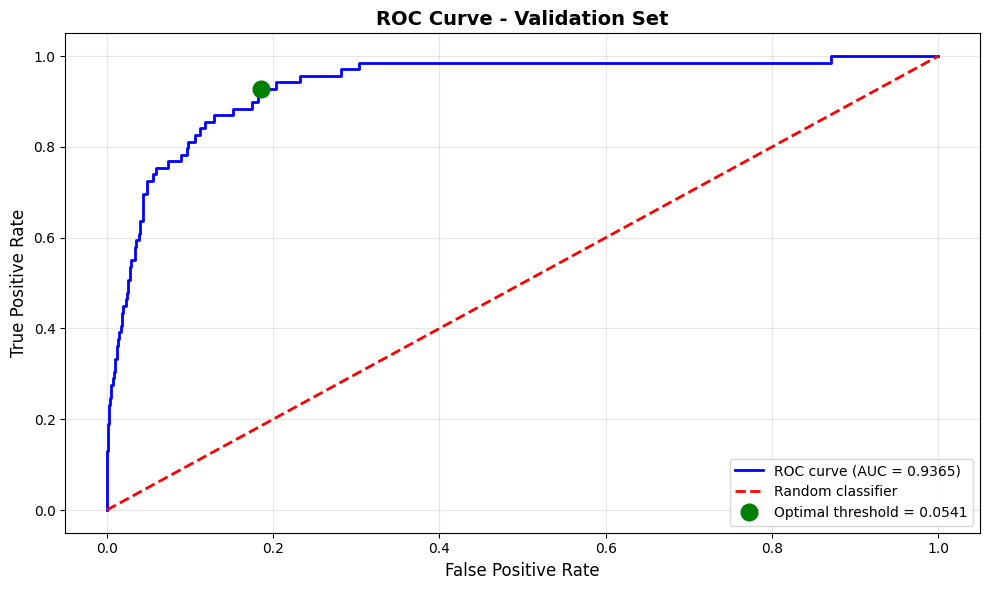

In [19]:
# Find optimal threshold on validation set
print("Finding optimal classification threshold...")

# Get validation predictions from best model
checkpoint = torch.load(results_dir / 'best_hybrid_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
_, _, val_preds, val_labels = validate(model, val_loader, criterion, device)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(val_labels, val_preds)

# Find optimal threshold (maximize Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print(f"  TPR at threshold: {tpr[optimal_idx]:.4f}")
print(f"  FPR at threshold: {fpr[optimal_idx]:.4f}")
print(f"  Youden's J: {j_scores[optimal_idx]:.4f}\n")

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {best_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random classifier')
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'go', markersize=12, 
         label=f'Optimal threshold = {optimal_threshold:.4f}')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Validation Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / 'roc_curve.png', dpi=150, bbox_inches='tight')
print(f"✓ ROC curve saved: {results_dir / 'roc_curve.png'}\n")
plt.show()

# Save threshold info
with open(results_dir / 'optimal_threshold.json', 'w') as f:
    json.dump({
        'optimal_threshold': float(optimal_threshold),
        'tpr': float(tpr[optimal_idx]),
        'fpr': float(fpr[optimal_idx]),
        'youden_j': float(j_scores[optimal_idx])
    }, f, indent=2)

## 10. Training History Plots

✓ Training plots saved: results/hybrid_model_20251107_161422/training_history.png



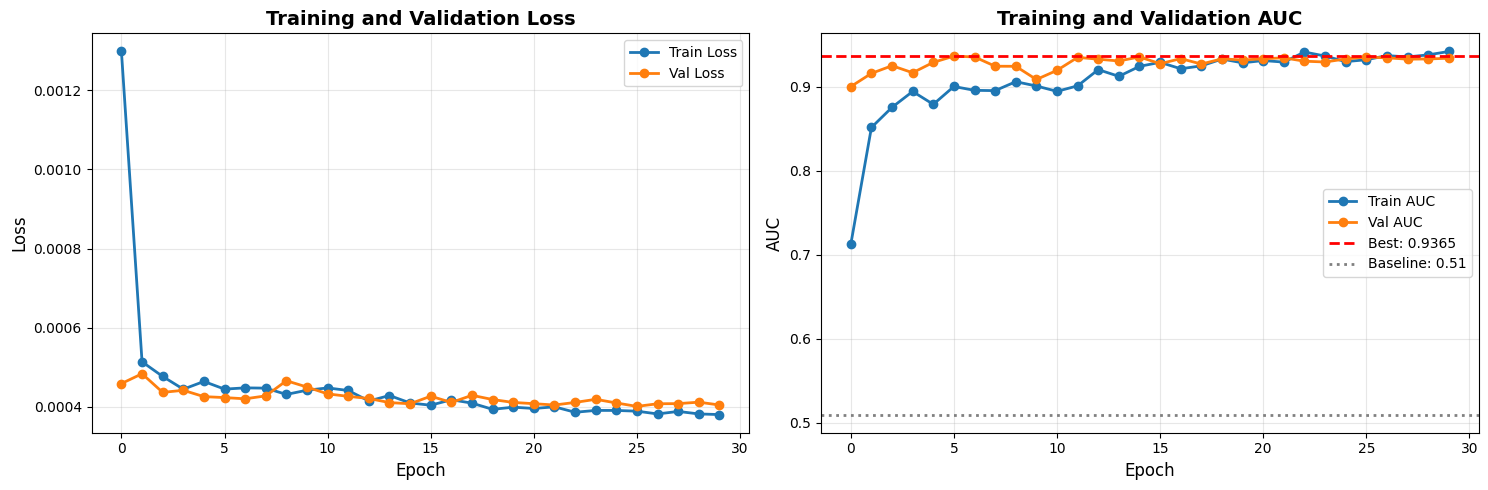

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].plot(history['train_auc'], label='Train AUC', marker='o', linewidth=2)
axes[1].plot(history['val_auc'], label='Val AUC', marker='o', linewidth=2)
axes[1].axhline(y=best_auc, color='r', linestyle='--', linewidth=2, 
                label=f'Best: {best_auc:.4f}')
axes[1].axhline(y=0.51, color='gray', linestyle=':', linewidth=2, 
                label='Baseline: 0.51')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('AUC', fontsize=12)
axes[1].set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'training_history.png', dpi=150, bbox_inches='tight')
print(f"✓ Training plots saved: {results_dir / 'training_history.png'}\n")
plt.show()

## 11. Generate Test Predictions

In [22]:
print("Generating test predictions...")

# Load best model
checkpoint = torch.load(results_dir / 'best_hybrid_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_ids = []
test_preds = []

with torch.no_grad():
    for images, metadata, img_ids in tqdm(test_loader, desc="Testing", ncols=100):
        images = images.to(device, non_blocking=True)
        metadata = metadata.to(device, non_blocking=True)
        
        outputs = model(images, metadata)
        probs = torch.sigmoid(outputs).cpu().numpy()
        
        test_ids.extend(img_ids)
        test_preds.extend(probs.flatten())

# Create submission
submission = pd.DataFrame({
    'isic_id': test_ids,
    'target': test_preds
})

submission.to_csv(results_dir / 'submission_hybrid_model.csv', index=False)

print(f"\n{'='*70}")
print("SUBMISSION GENERATED")
print(f"{'='*70}")
print(f"File: submission_hybrid_model.csv")
print(f"Shape: {submission.shape}")
print(f"\nPrediction statistics:")
print(submission['target'].describe())
print(f"{'='*70}\n")

Generating test predictions...


Testing: 100%|████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.10s/it]


SUBMISSION GENERATED
File: submission_hybrid_model.csv
Shape: (100, 2)

Prediction statistics:
count    100.000000
mean       0.088968
std        0.075216
min        0.010869
25%        0.028094
50%        0.055894
75%        0.153925
max        0.242053
Name: target, dtype: float64



## 12. Final Summary

In [25]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nModel Architecture:")
print(f"  - Hybrid: CNN (images) + MLP (metadata)")
print(f"  - Image features: {len(NUMERICAL_FEATURES)} numerical + {len(CATEGORICAL_FEATURES)} categorical")
print(f"  - Total metadata dimension: {metadata_dim}")
print(f"  - Total parameters: {total_params:,}")

print(f"\nTraining Configuration:")
print(f"  - Loss: Focal Loss (alpha=0.25, gamma=2.0)")
print(f"  - Optimizer: Adam (lr=0.001)")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Epochs trained: {len(history['train_auc'])}")
print(f"  - Total time: {total_time/60:.1f} minutes")

print(f"\nPerformance:")
print(f"  - Baseline AUC: 0.51 (image-only model)")
print(f"  - Best validation AUC: {best_auc:.4f}")
print(f"  - Improvement: +{(best_auc - 0.51):.4f} ({(best_auc - 0.51)/0.51*100:.1f}%)")
print(f"  - Optimal threshold: {optimal_threshold:.4f}")

print(f"\nFiles Generated in {results_dir}:")
print(f"  - best_hybrid_model.pth (model checkpoint)")
print(f"  - training_results.pkl (all training data - history, metrics, etc.)")
print(f"  - training_config.json (configuration summary)")
print(f"  - preprocessors.pkl (scaler and encoders)")
print(f"  - submission_hybrid_model.csv (test predictions)")
print(f"  - training_history.png (training plots)")
print(f"  - roc_curve.png (ROC curve)")
print(f"  - optimal_threshold.json (threshold tuning results)")

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Submit to Kaggle and check leaderboard AUC")
print("2. If AUC is still low, try:")
print("   - Pretrained CNN (ResNet18/EfficientNet)")
print("   - More aggressive data augmentation")
print("   - Ensemble multiple models")
print("   - Feature engineering on metadata")
print("3. Analyze misclassified examples")
print("="*70)

FINAL SUMMARY

Model Architecture:
  - Hybrid: CNN (images) + MLP (metadata)
  - Image features: 15 numerical + 4 categorical
  - Total metadata dimension: 34
  - Total parameters: 26,272,513

Training Configuration:
  - Loss: Focal Loss (alpha=0.25, gamma=2.0)
  - Optimizer: Adam (lr=0.001)
  - Batch size: 512
  - Epochs trained: 30
  - Total time: 75.8 minutes

Performance:
  - Baseline AUC: 0.51 (image-only model)
  - Best validation AUC: 0.9365
  - Improvement: +0.4265 (83.6%)
  - Optimal threshold: 0.0541

Files Generated in results/hybrid_model_20251107_161422:
  - best_hybrid_model.pth (model checkpoint)
  - training_results.pkl (all training data - history, metrics, etc.)
  - training_config.json (configuration summary)
  - preprocessors.pkl (scaler and encoders)
  - submission_hybrid_model.csv (test predictions)
  - training_history.png (training plots)
  - roc_curve.png (ROC curve)
  - optimal_threshold.json (threshold tuning results)

NEXT STEPS:
1. Submit to Kaggle and chec

## 13. Loading Previous Results (Optional)

If you want to load a previous training run later (after restarting the notebook), use the code below:

In [ ]:
# Example: Load a specific training run
def load_training_results(results_folder=None):
    """
    Load results from a previous training run.
    
    Args:
        results_folder: Path to results folder (e.g., 'results/hybrid_model_20241107_123456')
                       If None, loads the most recent run.
    
    Returns:
        Dictionary with all training results and objects
    """
    results_base = Path('results')
    
    if results_folder is None:
        # Find most recent results folder
        result_folders = sorted(results_base.glob('hybrid_model_*'))
        if not result_folders:
            raise ValueError("No existing results found!")
        results_dir = result_folders[-1]
    else:
        results_dir = Path(results_folder)
        if not results_dir.exists():
            raise ValueError(f"Results folder not found: {results_dir}")
    
    print(f"Loading results from: {results_dir}")
    
    # Load training results
    with open(results_dir / 'training_results.pkl', 'rb') as f:
        results = pickle.load(f)
    
    # Load preprocessors
    with open(results_dir / 'preprocessors.pkl', 'rb') as f:
        preprocessors = pickle.load(f)
    
    # Load configuration
    with open(results_dir / 'training_config.json', 'r') as f:
        config = json.load(f)
    
    # Load threshold if exists
    threshold_file = results_dir / 'optimal_threshold.json'
    if threshold_file.exists():
        with open(threshold_file, 'r') as f:
            threshold_data = json.load(f)
    else:
        threshold_data = None
    
    print(f"✓ Loaded training run: {results['timestamp']}")
    print(f"  Best AUC: {results['best_auc']:.4f}")
    print(f"  Epochs: {results['num_epochs']}")
    print(f"  Total time: {results['total_time']/60:.1f} minutes\n")
    
    return {
        'results_dir': results_dir,
        'results': results,
        'preprocessors': preprocessors,
        'config': config,
        'threshold_data': threshold_data
    }

# Example usage:
# loaded = load_training_results()  # Load most recent
# loaded = load_training_results('results/hybrid_model_20241107_123456')  # Load specific run

# Access components:
# history = loaded['results']['history']
# best_auc = loaded['results']['best_auc']
# scaler = loaded['preprocessors']['scaler']
# encoders = loaded['preprocessors']['encoders']

---

## 📁 Results Directory Structure

Each training run creates a timestamped folder in `results/` with the following files:

```
results/hybrid_model_YYYYMMDD_HHMMSS/
├── best_hybrid_model.pth          # Model checkpoint (state dict, optimizer, etc.)
├── training_results.pkl            # Complete training history and metrics
├── training_config.json            # Human-readable configuration summary
├── preprocessors.pkl               # Scaler and encoders for metadata
├── optimal_threshold.json          # Best classification threshold info
├── submission_hybrid_model.csv     # Test predictions for Kaggle
├── training_history.png            # Loss and AUC plots
└── roc_curve.png                   # ROC curve with optimal threshold
```

## 🔄 Workflow Options

### Option 1: Train a new model
1. Set `LOAD_EXISTING_RESULTS = False` in cell 2
2. Run all cells normally
3. Results saved automatically to `results/hybrid_model_<timestamp>/`

### Option 2: Load previous results (skip training)
1. Set `LOAD_EXISTING_RESULTS = True` in cell 2
2. Optionally specify `RESULTS_FOLDER = 'results/hybrid_model_YYYYMMDD_HHMMSS'`
3. Run all cells - training loop will be skipped
4. Can regenerate visualizations, make new predictions, etc.

### Option 3: Compare multiple runs
```python
# Load and compare different training runs
run1 = load_training_results('results/hybrid_model_20241107_120000')
run2 = load_training_results('results/hybrid_model_20241107_150000')

print(f"Run 1 AUC: {run1['results']['best_auc']:.4f}")
print(f"Run 2 AUC: {run2['results']['best_auc']:.4f}")

# Plot histories side by side
plt.plot(run1['results']['history']['val_auc'], label='Run 1')
plt.plot(run2['results']['history']['val_auc'], label='Run 2')
plt.legend()
plt.show()
```

## 💡 Benefits

- **No retraining needed** to regenerate plots or analyze results
- **Version control** - each run is preserved with timestamp
- **Easy comparison** between different hyperparameters or architectures
- **Reproducibility** - all settings and preprocessors saved
- **Fast iteration** - quickly test visualization changes without waiting for training